# Regression from scratch

This notebook estimates the Cox proportional-hazards coefficients directly from covariates prepared from `./felony-1989-final.xlsx`. It does not use Sirakaya's fitted coefficients.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import CoxPHFitter
from scipy.stats import chi2

import input

RESULTS_DIR = Path("results/regression-without-sirakaya")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR

PosixPath('results/regression-without-sirakaya')

## Load covariates and recompute county statistics

Use the imputed covariate table and recompute the two county statistics needed by the Cox formula.

In [3]:
input.clear_cached()
_, df, _, _ = input.load_data()

county_statistics = (
    df.groupby("code_county")
    .agg(
        mean_re_time=("time", "mean"),
        percent_re=("observed", "mean"),
    )
)

print("imputed rows:", len(df))
print("counties:", len(county_statistics))
display(county_statistics.head())

Loading data from Excel file...


/Users/brent/workspace/aaa-large-paper-projects/archived/23-fairness-facct/code-simul-diversion/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/brent/workspace/aaa-large-paper-projects/archived/23-fairness-facct/code-simul-diversion/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/brent/workspace/aaa-large-paper-projects/archived/23-fairness-facct/code-simul-diversion/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/brent/workspace/aaa-large-paper-projects/archived/23-fairness-facct/code-simul-diversion/.venv/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/brent/workspace/aaa-large-paper-projects/archived/23

Saving data to pickle cache in /Users/brent/workspace/aaa-large-paper-projects/archived/23-fairness-facct/code-simul-diversion/simulation/bin...
imputed rows: 9374
counties: 32


,mean_re_time,percent_re
code_county,,
1.0,700.922026,0.431734
2.0,694.578275,0.402930
3.0,842.475559,0.266447
4.0,799.080079,0.281726
5.0,496.242112,0.413146


## Assemble the columns

Each categorical variable is rounded after imputation, restricted to its documented level range, and marked as categorical. Level 1 is the reference category.

In [4]:
categorical_levels = {
    "employ": 3,
    "felony_prior_conviction": 3,
    "offense_type": 8,
    "sex": 2,
    "ethnicity": 2,
    "drug_abuse": 3,
    "race": 5,
    "supervision": 6,
    "age_dist": 6,
}
county_columns = ["house_female", "tax_property"]
county_statistic_columns = ["mean_re_time", "percent_re"]

cox_data = df.merge(
    county_statistics,
    left_on="code_county",
    right_index=True,
    how="left",
)

model_columns = (
    list(categorical_levels)
    + county_columns
    + county_statistic_columns
    + ["felony_arrest", "time", "observed"]
)
cox_data = cox_data[model_columns].dropna().copy()
# Felony arrests during the observed probation period.
cox_data["offenses"] = cox_data["felony_arrest"].round()
cox_data["time"] = cox_data["time"].clip(lower=1.0)
cox_data["observed"] = (cox_data["observed"] > 0).astype(int)

for column, number_of_levels in categorical_levels.items():
    cox_data[column] = (
        cox_data[column]
        .round()
        .clip(1, number_of_levels)
        .astype(int)
        .astype("category")
    )

print("modeling frame:", cox_data.shape)
print("observed events:", int(cox_data["observed"].sum()))
display(cox_data.head())

modeling frame: (9374, 17)
observed events: 3550


,employ,felony_prior_conviction,offense_type,sex,ethnicity,drug_abuse,race,supervision,age_dist,house_female,tax_property,mean_re_time,percent_re,felony_arrest,time,observed,offenses
0,1,1,8,1,2,1,2,3,6,0.325648,0.644054,700.922026,0.431734,0.0,1165.000000,0,0.0
1,1,1,8,1,2,1,2,3,5,0.325648,0.644054,700.922026,0.431734,0.0,1110.000000,0,0.0
2,3,2,2,1,2,1,2,4,6,0.325648,0.644054,700.922026,0.431734,1.0,453.331773,1,1.0
3,3,2,5,1,2,2,2,4,1,0.325648,0.644054,700.922026,0.431734,1.0,453.331773,1,1.0
4,2,3,7,1,2,2,2,5,4,0.325648,0.644054,700.922026,0.431734,0.0,494.000000,0,0.0


## Fit the Cox proportional-hazards model

This is an unpenalized maximum-likelihood fit. 
- If it reports convergence or singular-matrix problems, inspect collinearity, sparse levels, and event counts before changing the specification.
- Here, I add a large penalty to it as an example

In [10]:
cox_formula = " + ".join(
    list(categorical_levels)
    + county_columns
    + county_statistic_columns
    + ["offenses"]
)

cox_model = CoxPHFitter(penalizer=0.2)
cox_model.fit(
    cox_data,
    duration_col="time",
    event_col="observed",
    formula=cox_formula,
    show_progress=True,
)

cox_model.print_summary(decimals=4)
cox_model.summary.to_csv(
    RESULTS_DIR / "cox_coefficient_summary.csv"
)

Iteration 1: norm_delta = 6.86e-01, step_size = 0.9500, log_lik = -30815.52319, newton_decrement = 1.36e+03, seconds_since_start = 0.0
Iteration 2: norm_delta = 6.59e+00, step_size = 0.9500, log_lik = -56511.98107, newton_decrement = 2.64e+05, seconds_since_start = 0.1
Iteration 3: norm_delta = 2.16e+00, step_size = 0.2375, log_lik = -35762.17449, newton_decrement = 7.71e+03, seconds_since_start = 0.1
Iteration 4: norm_delta = 1.00e+00, step_size = 0.3026, log_lik = -31861.20320, newton_decrement = 2.51e+03, seconds_since_start = 0.2
Iteration 5: norm_delta = 3.50e-01, step_size = 0.5114, log_lik = -31514.65535, newton_decrement = 1.35e+03, seconds_since_start = 0.2
Iteration 6: norm_delta = 5.26e-02, step_size = 0.8642, log_lik = -30107.12142, newton_decrement = 1.83e+02, seconds_since_start = 0.2
Iteration 7: norm_delta = 2.22e-02, step_size = 1.0000, log_lik = -29885.49230, newton_decrement = 4.02e+01, seconds_since_start = 0.3
Iteration 8: norm_delta = 1.14e-02, step_size = 1.0000,

<lifelines.CoxPHFitter: fitted with 9374 total observations, 5824 right-censored observations>
             duration col = 'time'
                event col = 'observed'
                penalizer = 0.2
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 9374
number of events observed = 3550
   partial log-likelihood = -29831.2002
         time fit was run = 2026-08-21 12:57:30 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
employ[T.2]                   0.1167    1.1238    0.0321          0.0538          0.1797              1.0552              1.1969
employ[T.3]                   0.2226    1.2493    0.0307          0.1624          0.2828              1.1763              1.3269
felony_prior_conviction[T.2]  0.2228    1.2495    0.0398          0.1447          0.3008              1.1557              1.3510
felony_prior_conviction[T.3]  0.2630    1.3008    0.0421          0.1806          0.3454              1.1979              1.4126
offense_type[T.2]            -0.4001    0.6702    0.0586         -0.5150         -0.2853              0.5975              0.7518
offense_type[T.3]             0.1330    1.1422    0.0467          0.0414          0.2246              1.0423              1.2518
offense_type[T.4]            -0.1567    0.8549    0.0482         -0.2511         -0.0624              0.7779              0.9395
offense_type[T.5]             0.2400    1.2713    0.0398          0.1621          0.3180              1.1759              1.3744
offense_type[T.6]             0.1434    1.1542    0.0425          0.0602          0.2266              1.0620              1.2544
offense_type[T.7]            -0.0738    0.9289    0.0399         -0.1520          0.0045              0.8590              1.0045
offense_type[T.8]             0.0409    1.0417    0.0372         -0.0321          0.1139              0.9684              1.1206
sex[T.2]                     -0.2429    0.7844    0.0425         -0.3263         -0.1595              0.7216              0.8526
ethnicity[T.2]               -0.1671    0.8461    0.0368         -0.2393         -0.0950              0.7872              0.9094
drug_abuse[T.2]               0.0707    1.0732    0.0307          0.0105          0.1308              1.0106              1.1397
drug_abuse[T.3]               0.2589    1.2955    0.0333          0.1936          0.3242              1.2137              1.3829
race[T.2]                     0.2812    1.3247    0.0299          0.2225          0.3398              1.2492              1.4047
race[T.3]                     0.0430    1.0439    0.1377         -0.2268          0.3128              0.7970              1.3673
race[T.4]                    -0.1257    0.8819    0.0936         -0.3092          0.0579              0.7340              1.0596
race[T.5]                     0.0805    1.0838    0.1498         -0.2130          0.3740              0.8081              1.4535
supervision[T.3]             -0.2912    0.7474    0.0407         -0.3709         -0.2114              0.6901              0.8095
supervision[T.4]              0.0690    1.0714    0.0319          0.0064          0.1315              1.0065              1.1405
supervision[T.5]              0.3666    1.4428    0.0393          0.2895          0.4436              1.3357              1.5583
supervision[T.6]              0.4298    1.5370    0.0628          0.3068          0.5529              1.3591              1.7382
age_dist[T.2]                 0.0547    1.0562    0.0327         -0.0095          0.1188              0.9906              1.1261
age_dist[T.3]                -0.0245    0.9758    0.0346         -0.0924          0.0434              0.9117              1.0443
age_dist[T.4]                -0.2002    0.8185    0.0365         -0.2717         -0.1

## Joint tests for categorical variables

The coefficient table tests individual dummy levels. This cell adds one joint Wald test for each complete categorical variable.

In [11]:
coefficients = cox_model.params_
covariance = cox_model.variance_matrix_
wald_rows = []

for column in categorical_levels:
    coefficient_names = [
        name
        for name in coefficients.index
        if name == column
        or name.startswith(column + "[")
        or name.startswith(column + "_")
    ]

    beta = coefficients.loc[coefficient_names].to_numpy()
    covariance_block = covariance.loc[
        coefficient_names, coefficient_names
    ].to_numpy()
    statistic = float(
        beta @ np.linalg.solve(covariance_block, beta)
    )

    wald_rows.append(
        {
            "covariate": column,
            "df": len(coefficient_names),
            "wald_chi2": statistic,
            "p_value": chi2.sf(statistic, len(coefficient_names)),
        }
    )

joint_wald_tests = pd.DataFrame(wald_rows)
joint_wald_tests.to_csv(
    RESULTS_DIR / "cox_joint_wald_tests.csv",
    index=False,
)
display(joint_wald_tests)

,covariate,df,wald_chi2,p_value
0,employ,2,53.524463,2.384023e-12
1,felony_prior_conviction,2,62.272045,3.004674e-14
2,offense_type,7,138.696044,9.533567e-27
3,sex,1,32.577814,1.145145e-08
4,ethnicity,1,20.613772,5.619045e-06
5,drug_abuse,2,60.457302,7.444981e-14
6,race,4,92.800882,3.344467e-19
7,supervision,4,219.842751,2.026602e-46
8,age_dist,5,105.069132,4.507124e-21


## Save scores, baseline survival, and plots

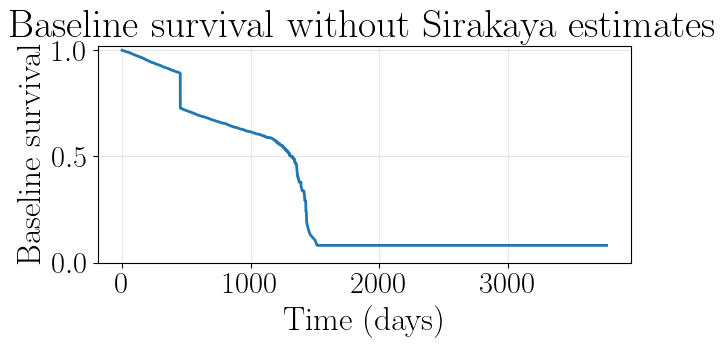

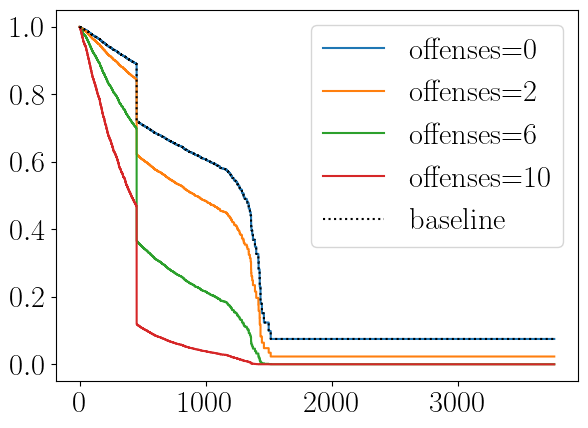

In [12]:
cox_data["score_fitted"] = cox_model.predict_log_partial_hazard(
    cox_data
)
baseline_survival = cox_model.baseline_survival_

cox_data.to_csv(
    RESULTS_DIR / "cox_individual_scores.csv",
    index=False,
)
baseline_survival.to_csv(
    RESULTS_DIR / "cox_baseline_survival.csv"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(
    baseline_survival.index,
    baseline_survival.iloc[:, 0],
    linewidth=2,
)
ax.set_xlabel("Time (days)")
ax.set_ylabel("Baseline survival")
ax.set_title("Baseline survival without Sirakaya estimates")
ax.set_ylim(0, 1.02)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(
    RESULTS_DIR / "cox_baseline_survival.png",
    dpi=300,
)
plt.show()

cox_model.plot_partial_effects_on_outcome(
    covariates="offenses",
    values=[0, 2, 6, 10],
)
plt.tight_layout()
plt.savefig(
    RESULTS_DIR / "cox_offense_partial_effects.png",
    dpi=300,
)
plt.show()

## Handoff

The files under `results/regression-without-sirakaya/` are analysis outputs; 
- `run_policy.py` does not load them automatically. 
- If this fit supports a model change, update and record the simulator code before running the policy simulation.